# 数据科学/数据处理的通用框架流程

文件来源： 此文件出自Python For Beginner学习社群。

作者： 闫小峰

Last Update: 2026-02-13

## 数据处理通用框架/流程模板

[0. 业务理解 Understanding](#0) 

[1. 数据获取和理解 ](#1)
- 数据分析环境设置 Set Up Environment
- 数据获取/采样
- 数据探索  
  - 熟悉数据属性
  - 数据体检： Sanity Checking 

[2. 预处理 Data Preparation](#2)  
- 数据清理  Data Cleaning 
- 数据准备，转换和调整


[3. 数据分析和挖掘 Data Analysis / Data  Mining](#3)
- 传统（经典）数据分析： 
  - 统计学方法 
  - 建模： 业务分析模型
- 机器学习 Machine Learning: 
  - 模型构建: 训练-测试-调试， 
  - 模型预测
- AI增强/辅助型数据分析和开发
  - LLM

[4. 模型评估  Model Evaluation ](#4)


[5. 业务理解/知识深化和提升](#5)
- 数据处理流程自动化 Pipelines
- X by Data Based/Data Driven
   -  Decision Making
   -  Story Line
   -  逻辑论证
   -  发现规律 etc

# 0.业务理解Understanding

- 目标和需求分析：数据分析的背景，动机和目的：
  - 学习如何从大数据中挖掘信息和使用价值
      - 数据类型：金融数据
      - 来源：美国股市历史数据， 。。。
  - 学习金融领域的基本和底层模型，并学会使用金融模型结合结合经典统计学（和现代机器学习算法）进行分析
  - 学习提出自己的假设并利用上述知识进行验证
  - 将学习的金融知识融入到实战中，运用场景：资产配置
- 操作执行战术分析：数据分析需要的方法
  - 灵活使用numpy和pandas的数据结构进行数据处理和计算，并熟练掌握两者之间的互相转换
  - 学会调用函数（创建，导入自创库，Function Call）

### 1. 数据获取和理解 Get Data & Data Understanding <a id="1"></a>

### 1.1. 数据处理环境设置 Set Up Environment <a id="1.1"></a>

In [1]:
# import modules for data science 
import numpy as np
import pandas as pd

#import module for plotting
import matplotlib.pyplot as plt 

# import customer modules
import utils as myfin  

import warnings
warnings.filterwarnings('ignore') #to suppress warning messages

%load_ext autoreload
%autoreload 2
%matplotlib inline

## 1.2. 数据获取

### 1.2.1. 小测试样本数据

In [3]:
prices = pd.read_csv("data/sample_prices.csv")
prices 

,STOCK1,STOCK2
0,8.7000,10.6600
1,8.9055,11.0828
2,8.7113,10.7100
3,8.4346,11.5907
4,8.7254,12.1070
5,9.0551,11.7876
6,8.9514,11.2078
7,9.2439,12.5192
8,9.1276,13.3624
9,9.3976,14.4080


In [6]:
# calculate returns
returns = prices/prices.shift(1)-1 
returns

# print(prices.shift(1))


,STOCK1,STOCK2
0,NaN,NaN
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249


In [7]:
# calculate daily returns with alternative method
returns_alt = prices.pct_change()
returns_alt

,STOCK1,STOCK2
0,NaN,NaN
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249


In [8]:
returns_alt = returns_alt.dropna()
returns_alt

,STOCK1,STOCK2
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249
10,0.006151,-0.168261


In [10]:
returns_alt.mean()
display(returns_alt.std())

STOCK1    0.023977
STOCK2    0.079601
dtype: float64

<Axes: >

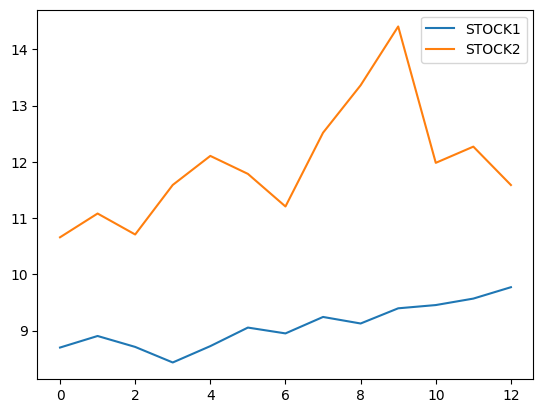

In [11]:
prices.plot()

### 1.2.2. 美国股市历史数据

来源：
- Kenneth French： https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html#Research

#### Real US history data of 10 portfolios

Read in the monthly returns of a set of 10 portfolios formed on market caps, or market equities of the companies. we only want to look at the largest cap and the smallest cap companies:

In [3]:
# # input source data
me_m = pd.read_csv("data/Portfolios_Formed_on_ME.csv",
#                    header=7, index_col=0,skipfooter=1197, parse_dates=True, na_values=-99.99,engine='python') 
                     header=7, index_col=0, nrows=1192, parse_dates=True, na_values=-99.99,engine='python')# 
# me_m.shape
# #me_m.head()
me_m.tail()

,<= 0,Lo 30,Med 40,Hi 30,Lo 20,Qnt 2,Qnt 3,Qnt 4,Hi 20,Lo 10,2-Dec,3-Dec,4-Dec,5-Dec,6-Dec,7-Dec,8-Dec,9-Dec,Hi 10
202505,NaN,6.92,5.37,6.46,6.27,5.75,4.81,5.83,6.51,8.72,4.54,7.65,4.72,4.64,4.92,6.31,5.59,6.17,6.56
202506,NaN,6.05,4.22,5.25,6.77,6.03,4.28,3.85,5.32,6.11,7.24,5.27,6.46,4.49,4.14,3.26,4.15,3.88,5.51
202507,NaN,2.06,1.74,2.37,1.82,1.53,1.71,1.80,2.41,2.34,1.47,2.32,1.02,1.66,1.75,2.03,1.68,1.90,2.47
202508,NaN,9.18,5.21,1.92,9.32,8.61,5.96,3.34,1.83,8.28,10.03,9.04,8.34,5.67,6.18,3.23,3.41,1.52,1.87
202509,NaN,2.19,0.61,3.98,3.42,0.93,0.94,0.19,4.19,5.18,2.23,0.87,0.97,1.28,0.69,0.07,0.25,1.03,4.58


In [4]:
# select only small cap and large cap portfolios
returns = me_m[['Lo 10','Hi 10']]
returns.head()

,Lo 10,Hi 10
192607,-0.62,3.67
192608,1.65,3.79
192609,0.57,1.26
192610,-4.29,-2.56
192611,-3.18,2.45


#### IND30 Ken French Dataset

The Ken French dataset contains the returns of 30 different industry portfolios.

In [2]:
ind = myfin.get_ind_returns()
ind.tail()
#er = myfin.annualize_rets(ind["1996":"2000"], 12)
#cov = ind["1996":"2000"].cov()

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
2025-05,-0.0047,-0.0344,0.0462,0.0649,0.0430,0.0410,0.1027,-0.0396,0.0233,-0.0271,...,0.0386,0.1110,0.0928,0.0453,0.0727,0.0238,0.0647,0.0368,0.0430,0.0123
2025-06,-0.0067,-0.0167,0.0075,0.1010,0.0356,-0.0391,0.0201,0.0201,0.0034,0.0459,...,0.0363,0.0645,0.1079,-0.0212,0.0475,0.0155,0.0275,0.0196,0.0551,-0.0102
2025-07,-0.0226,0.0338,-0.0584,-0.0831,-0.0334,-0.0310,0.0251,-0.0127,-0.0067,0.0095,...,-0.0336,0.0445,0.0612,-0.0138,-0.0206,0.0014,0.0311,-0.0251,-0.0068,-0.0254
2025-08,0.0185,0.0349,0.0387,0.0508,0.0582,0.0327,0.0425,0.0474,0.0634,0.1747,...,0.0380,-0.0106,0.0339,0.0402,0.0421,0.0154,0.0085,0.0088,0.0418,0.0443
2025-09,-0.0221,-0.0712,-0.0209,-0.0175,0.0086,-0.0354,-0.0542,0.0203,-0.0463,-0.0335,...,-0.0113,0.0479,0.0813,-0.0391,0.0049,0.0080,-0.0106,-0.0461,0.0117,-0.0007


#### 因子模型数据

巴菲特BRKA月回报数据，Fama-French模型数据。

In [31]:
brka_m = pd.read_csv("data/brka_m.csv", parse_dates=True, index_col=0)
brka_m.tail()

,BRKA
DATE,
2018-08-01,0.047256
2018-09-01,0.013300
2018-10-01,-0.038422
2018-11-01,0.059456
2018-12-01,-0.061350


In [33]:
fff = myfin.get_fff_returns()
fff.tail()

,Mkt-RF,SMB,HML,RF
2018-08,0.0344,0.0123,-0.0412,0.0016
2018-09,0.0006,-0.0237,-0.0134,0.0015
2018-10,-0.0768,-0.0468,0.0341,0.0019
2018-11,0.0169,-0.0074,0.0020,0.0018
2018-12,-0.0955,-0.0261,-0.0151,0.0019


# 2. 数据预处理 Data Preparation  <a id="2"></a>

## 2.1.1 US Market Monthly Portfolio Data Preparation

In [5]:
# convert percentage to decimal
returns = returns.apply(lambda s: pd.to_numeric(s, errors='coerce'))
returns.dtypes
returns = returns/100
returns.head()

,Lo 10,Hi 10
192607,-0.0062,0.0367
192608,0.0165,0.0379
192609,0.0057,0.0126
192610,-0.0429,-0.0256
192611,-0.0318,0.0245


<Axes: >

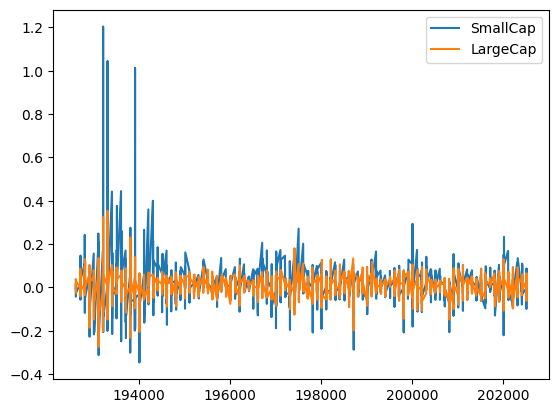

In [6]:
returns.columns = ['SmallCap','LargeCap']
returns.plot()

In [7]:
# 处理数据集中的时间戳
returns.index 
returns.index = pd.to_datetime(returns.index, format='%Y%m')
returns.index


DatetimeIndex(['1926-07-01', '1926-08-01', '1926-09-01', '1926-10-01',
               '1926-11-01', '1926-12-01', '1927-01-01', '1927-02-01',
               '1927-03-01', '1927-04-01',
               ...
               '2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01',
               '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01',
               '2025-08-01', '2025-09-01'],
              dtype='datetime64[ns]', length=1191, freq=None)

In [8]:
# Monthly data is an index that is date stamped. Fix this using the `to_period` method
returns.index = returns.index.to_period('M')
returns.index

PeriodIndex(['1926-07', '1926-08', '1926-09', '1926-10', '1926-11', '1926-12',
             '1927-01', '1927-02', '1927-03', '1927-04',
             ...
             '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05',
             '2025-06', '2025-07', '2025-08', '2025-09'],
            dtype='period[M]', length=1191)

✅我们可以把上述成功测试好的数据读取和初步处理流程固定下来，构建成一个自己的函数，放入自建库中备用

In [9]:
#数据处理好了以后可以任意使用了，比如取某一年的数据
returns["SmallCap"]['2023']

2023-01    0.1143
2023-02   -0.0412
2023-03   -0.0605
2023-04   -0.0132
2023-05   -0.0017
2023-06    0.0435
2023-07    0.0679
2023-08   -0.0833
2023-09   -0.0618
2023-10   -0.0769
2023-11    0.0594
2023-12    0.1349
Freq: M, Name: SmallCap, dtype: float64

# 3. 数据分析和探索，建模  Data Analysis & Data  Mining，Modelling <a id="3"></a>

## 3.1. 金融分析基础概念和模型

## 如何评估收益

基本收益指标：直观，简单好理解。

### 收益率（Returns）

return from time $t$ to time ${t+1} is given by:

$$ R_{t,t+1} = \frac{P_{t+1}-P_{t}}{P_{t}} $$

or alternately

$$ R_{t,t+1} = \frac{P_{t+1}}{P_{t}} - 1 $$


计算累计收益率时:
- 基于“复利式”计算方法：乘法因子 "1+R" format
- 回算收益率时需要做 -1 转换


In [19]:
# If you come from R or another language that supports vectors, you might expect something like this to work:

prices_a = np.array([10, 12, 14, 13, 15])
returns_a = prices_a[1:]/prices_a[:-1] - 1
returns_a

array([ 0.2       ,  0.16666667, -0.07142857,  0.15384615])

### 年化收益率（Annualizing Returns）

To annualize a return for a period, you compound the return for as many times as there are periods in a year. For instance, to annualize a monthly return you compund that return 12 times. The formula to annualize a monthly return $R_m$ is:

$$ (1+R_m)^{12} - 1$$

To annualize a quarterly return $R_q$ you would get:

$$ (1+R_q)^{4} - 1$$

And finally, to annualize a daily return $R_d$ you would get:

$$ (1+R_d)^{252} - 1$$

年化收益率的计算公式是**（投资内收益/本金/投资天数）×365×100%**。

对于复利投资，可以使用公式年化收益率 = (期末资产净值 / 期初资产净值)^365/投资天数- 1来计算。 
方法一：按天数计算（适用于非复利） 
•	公式：年化收益率 = (投资收益 / 本金 / 投资天数) × 365 × 100%
•	举例：
o	本金是10000元
o	投资了180天
o	获得了收益200元
o	年化收益率 = (200/10000/180) × 365 × 100% ≈ 4.06% 
方法二：复利计算 
•	公式：年化收益率 = (期末资产净值 / 期初资产净值)^(365/投资天)- 1
 
补充说明 
- 年化收益率是把当前收益率（日收益率、周收益率、月收益率）换算成年收益率来计算的，是一种**理论收益率**，并不是真正的已取得的收益率。
作用：提供一个可用衡量对比的基准
- 注意定义的模糊性： 有效时间的不同规定：一年的有效投资时间，对银行存款、票据、债券等D=360日，对于股票、期货等市场D=250日，对于房地产和实业等D=365日
- 在实际投资中，年化收益率会受市场波动等多种因素影响，可能与实际收益率不同。
- 对于货币基金、债券等有固定收益或定期调整收益的投资，实际收益率可能更接近年化收益率。 



## 如何评估风险

## 波动率（Volatility）

volatility is measured by the average squared deviation from the mean = standard deviation.

波动率是衡量金融资产价格在特定期间内波动程度的指标，通常以百分比或点数表示。它反映市场的活跃程度：波动率高代表价格剧烈波动，波动率低则表示价格相对稳定。


### Drawdown (The maximum drawdown)=max. loss回撤

回撤（或最大回撤）是另外一个（更真实）反应风险的评估指标。

Drawdowns计算算法：

1. Convert the time series of returns to a time series that represents a wealth index
2. Compute a time series of the previous peaks
3. Compute the Drawdown as the difference between the previous peak and the current value

### 半标准差 (Semideviation)

又称为半偏差或下偏标准差 (Downside Deviation)，是统计学和金融学中衡量风险的一种指标，主要关注投资回报低于特定目标值（通常是平均回报率或最低可接受回报率）时的波动性。 

核心概念
与传统的标准差（Standard Deviation）衡量数据围绕均值的双向波动不同，半标准差仅计算低于均值或预设目标的那些观测值的离散程度。其核心思想在于：对于投资者而言，高于预期的正收益通常不被视为“风险”，真正的风险在于收益低于预期或出现亏损。 

主要特点与用途
- 风险的不对称性：半标准差捕捉了金融市场中风险的不对称性，即人们更关心损失而非意外收益。
- 关注下行风险：它是一种专门度量“下行风险”（Downside Risk）的指标。


### 风险价值(Value at Risk)

风险价值(VaR)是一种统计度量，用于在**特定的时间范围**和给定的**置信度**水平上估计投资或投资组合的潜在损失。它提供了一种量化投资的下行风险的方法，并帮助投资者在风险管理和投资组合分配方面做出明智的决策。

VaR通常以负的金额表示，代表投资者在一定程度的信心下可以预期经历的最大损失。

## 从简单到晋级：如何在整体金融市场中评估收益

需要一下基本假设和基础模型。

### CAPM（资本资产定价模型）

CAPM（资本资产定价模型）是现代金融学最重要的模型，可以用来：计算资产的系统风险，估计资产的预期收益率，评价投资组合的业绩。 该模型在诺奖得主哈里·马科维茨（Harry Markowitz）的投资组合理论（又称均值方差理论）基础之上产生，由威廉·夏普（William Sharpe）正式提出

资本资产定价模型（CAPM）是现代金融理论中的一个基本概念，用于通过考虑投资相对于整体市场的内在风险来确定投资的预期回报率。 该模型提供了一种结构化的方法来评估风险和回报之间的权衡，这对于做出明智的投资决策来说是至关重要的。 资本资产定价模型中包含了三个主要的组成部分：无风险利率、β 系数和市场风险溢价

计算公式：
𝐸(𝑅𝑖)=𝑅𝑓+𝛽𝑖(𝐸(𝑅𝑚)−𝑅𝑓)

公式说明：
- 𝐸(𝑅𝑖)代表资产的预期收益率。
- 𝑅𝑓代表无风险利率。
- 𝛽𝑖代表资产的Beta值，衡量资产相对于市场波动的敏感度。
- 𝐸(𝑅𝑚)代表市场的平均预期收益率。
- (𝐸(𝑅𝑚)−𝑅𝑓)代表市场风险溢价。



夏普比率（Sharpe Ratio）

夏普比率是衡量投资效率的重要指标，它通过比较投资的超额回报与承担的风险来评估投资性价比。

计算公式为投资的超额收益（投资回报率减去无风险利率）除以投资的标准差（风险）： 


- 衡量投资效率： 它衡量的是在承担单位风险的情况下，能够获得的超额回报。 夏普比率越高，表明投资在承受单位风险下所获得的回报越高
- 比较不同投资： 夏普比率可以用来比较风险水平不同的金融产品，帮助判断哪种产品更具效率。

投资组合/资产配置理论中的底层概念和基础模型I - **`有效前沿（Efficient Frontier）`**
 
核心概念：
- 发明者：哈里·马科维茨（1990年诺贝尔经济学奖得主）。
- 核心思想：通过分散投资（不要把所有钱放在一个篮子里），可以构建在既定风险水平下收益最高、或在既定收益水平下风险最低的投资组合。

关键指标：
- 收益：用资产的预期收益率衡量。
- 风险：用收益率的标准差（波动性）衡量。

用大白话说明白：
有效前沿就是投资世界里的“最优解集合”，帮你找到风险和收益的最佳平衡点。

计算步骤（实战推导）
- 第一步：计算组合的预期收益（Expected Returns）
- 第二步：计算组合的风险（标准差）（Covariance Matrix）
- 第三步：遍历所有权重组合
- 第四步：绘制散点图（横轴：风险（标准差），纵轴：预期收益）并找出“有效前沿”

优缺点：
- 目标指导特性：投资组合有理论上一个最优值
- 局限：
  - 这个最优值是后视镜中的数值（因为只能从历史数据中进行计算），无法预测未来
  - 假设理想化：假设投资者只关心收益和标准差（现实中人还会考虑流动性、税收等）。
  - 动态变化：市场变化时，有效前沿会移动，需定期调整。



### 3.1.1. Data Analysis on Simple Prices Data

In [ ]:
returns = returns.dropna()
deviations = returns - returns.mean()
# deviations 
sq_deviations = deviations **2
#sq_deviations
meann_sq_dev = sq_deviations.mean()
# numpy
# volatility =  np.sqrt(meann_sq_dev)
#pandas
returns.std() 
volatility

NameError: name 'volatility' is not defined

### 3.1.2. Data Analysis on Portfolio Monthly Data

In [41]:
# calculate the annualized returns
n_month= returns.shape[0]
annualized_returns = ((1 + returns).prod())**(12/n_month) - 1
annualized_returns

NameError: name 'returns' is not defined

In [ ]:
# calculate the annualized volatility
month_to_year = 12  # monthly data
annualized_volatility = returns.std() * np.sqrt(month_to_year)
annualized_volatility

SmallCap    0.337115
LargeCap    0.174067
dtype: float64

<Axes: >

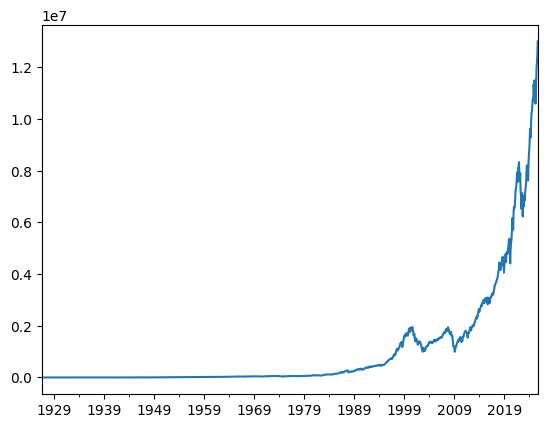

In [ ]:
# 风险评估方法：计算（最大）回撤
wealth_index = 1000*(1+returns["LargeCap"]).cumprod()
wealth_index.plot()



<Axes: >

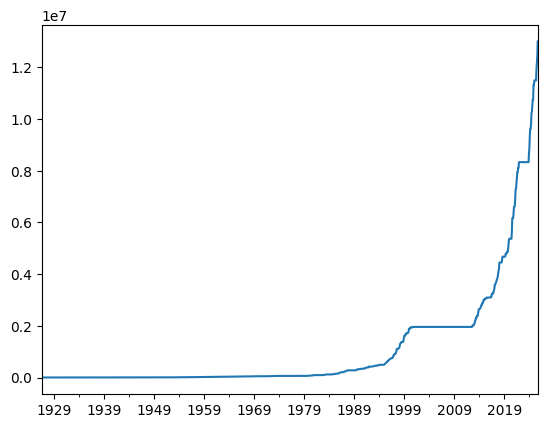

In [ ]:
previous_peaks = wealth_index.cummax()
previous_peaks.plot()

<Axes: >

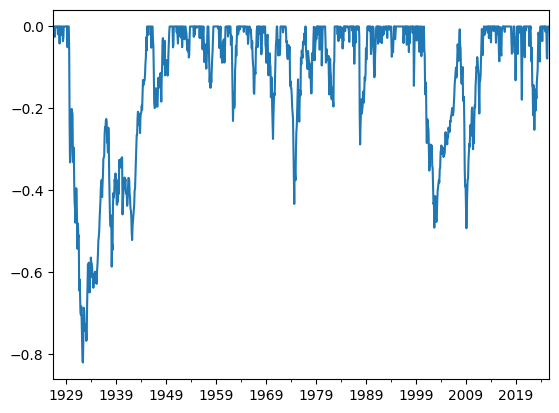

In [ ]:
drawdown = (wealth_index - previous_peaks)/previous_peaks
drawdown.plot()

In [ ]:
# find the max. drawdown
max_drawdown = drawdown.min()   
max_drawdown

np.float64(-0.8204179705764917)

<Axes: >

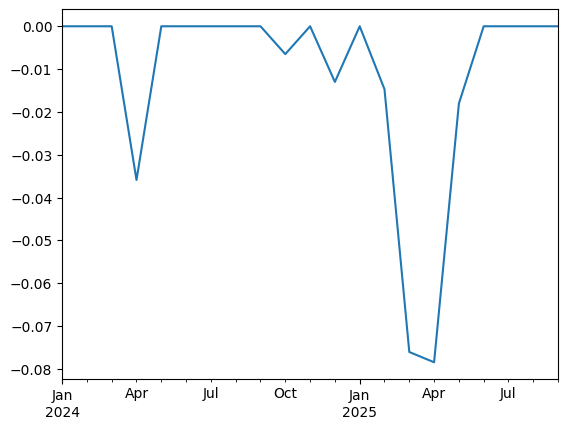

In [ ]:
# look for drawndown in any period
drawdown["2025"].min()
drawdown["2024":].plot()

<Axes: >

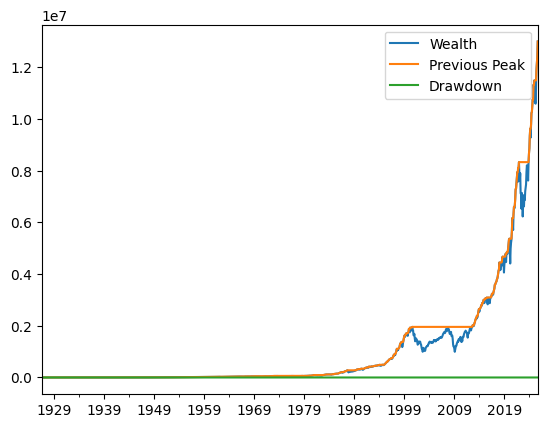

In [ ]:
# use user-defined function
#import utils as myfin
myfin.drawdown(returns["LargeCap"]).plot()

In [ ]:
myfin.drawdown(returns["LargeCap"]["2024"]).min()

Wealth           1024.2000
Previous Peak    1024.2000
Drawdown           -0.0359
dtype: float64

In [ ]:
# find the historic max. drowndown
myfin.drawdown(returns["LargeCap"])["Drawdown"]['2024'].idxmin()

Period('2024-04', 'M')

In [ ]:
# calculate the semideviation
myfin.semideviation(returns)

SmallCap    0.054291
LargeCap    0.037255
dtype: float64

In [ ]:
# calculate the VaR at 5% level using the historical meth
myfin.var_historic(returns["SmallCap"], level=5)

np.float64(0.11099999999999999)

我们可以使用这些风险概念（关键点：是可量化的指标）来分析和思考我们的投资选择和组合，然后做出合理的决策。

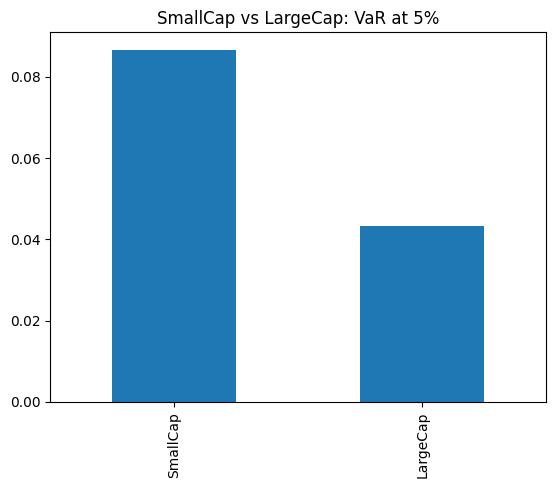

In [ ]:
var_small = myfin.var_historic(returns["SmallCap"]["2025"], level=5) 
var_large = myfin.var_historic(returns["LargeCap"]["2025"], level=5)
# print(type(var_small), type(var_large))

# If both are scalars -> create a Series for plotting
if isinstance(var_small, (int, float, np.floating)) and isinstance(var_large, (int, float, np.floating)):
    s = pd.Series({"SmallCap": float(var_small), "LargeCap": float(var_large)})
    s.plot.bar(title="SmallCap vs LargeCap: VaR at 5%")
else:
    # Ensure both are Series/DataFrame and align by index before concat
    s_small = pd.Series(var_small, name="SmallCap") if not isinstance(var_small, (pd.Series, pd.DataFrame)) else (var_small.rename("SmallCap") if isinstance(var_small, pd.Series) else var_small)
    s_large = pd.Series(var_large, name="LargeCap") if not isinstance(var_large, (pd.Series, pd.DataFrame)) else (var_large.rename("LargeCap") if isinstance(var_large, pd.Series) else var_large)
    comparison = pd.concat([s_small, s_large], axis=1)
    comparison.plot.bar(title="SmallCap vs LargeCap: VaR at 5%")

有了基本的收益和风险概念，进一步思考：
- 有没有一种投资可以“只赚不赔”？
- 有没有一种资产呈现出比其他资产更安全收益更高的特征？
  
本质上讲，就是要寻找一个指标可以衡量风险条件下的收益程度/高低。人们会自然想到比值法。

这里还需引入一个概念：无风险收益率。

最后的结果就是：`夏普比率`.

In [ ]:
annualized_returns/annualized_volatility

SmallCap    0.355694
LargeCap    0.575336
dtype: float64

In [ ]:
riskfree_rate = 0.04
excess_returns = annualized_returns - riskfree_rate
sharpe_ratio = excess_returns/annualized_volatility
sharpe_ratio

SmallCap    0.266704
LargeCap    0.402989
dtype: float64

### 3.1.3. Data Analysis on US Industry Monthly Data

In [3]:
# explore the industry data
print(f"Dateframe ind has the Shape: {ind.shape}")
print(f"Dataframe ind has column names: {ind.columns}")
ind.head()

Dateframe ind has the Shape: (1191, 30)
Dataframe ind has column names: Index(['Food', 'Beer', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths', 'Hlth',
       'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos', 'Carry',
       'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'Servs', 'BusEq', 'Paper',
       'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin', 'Other'],
      dtype='str')


,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
1926-07,0.0053,-0.0519,0.0129,0.0293,0.1097,-0.0049,0.0808,0.0185,0.0816,0.0050,...,0.0083,0.0932,0.0202,0.0770,0.0192,-0.2379,0.0008,0.0188,-0.0002,0.0520
1926-08,0.0262,0.2703,0.0652,0.0055,0.1001,-0.0358,-0.0250,0.0417,0.0547,0.0783,...,0.0217,0.0202,0.0443,-0.0237,0.0485,0.0539,-0.0076,-0.0013,0.0426,0.0676
1926-09,0.0116,0.0402,0.0126,0.0664,-0.0097,0.0072,-0.0050,0.0069,0.0542,0.0230,...,0.0242,0.0227,0.0018,-0.0554,0.0008,-0.0787,0.0025,-0.0056,-0.0163,-0.0358
1926-10,-0.0305,-0.0331,0.0107,-0.0476,0.0947,-0.0466,0.0012,-0.0057,-0.0475,0.0099,...,-0.0011,-0.0198,-0.0109,-0.0508,-0.0263,-0.1538,-0.0219,-0.0411,-0.0552,-0.0847
1926-11,0.0636,0.0729,0.0456,0.0166,-0.0587,-0.0053,0.0187,0.0543,0.0518,0.0319,...,0.0163,0.0377,0.0364,0.0385,0.0161,0.0467,0.0654,0.0433,0.0254,0.0416


In [4]:
# check returns
a_rets = myfin.annualize_rets(ind["2000":"2025"], 12)

<Axes: >

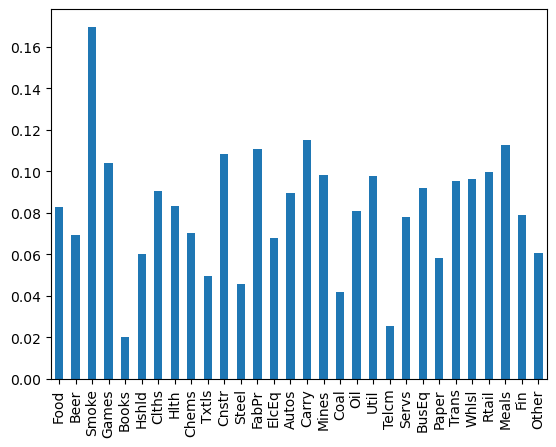

In [5]:
#plot the data 
a_rets.plot.bar()

<Axes: >

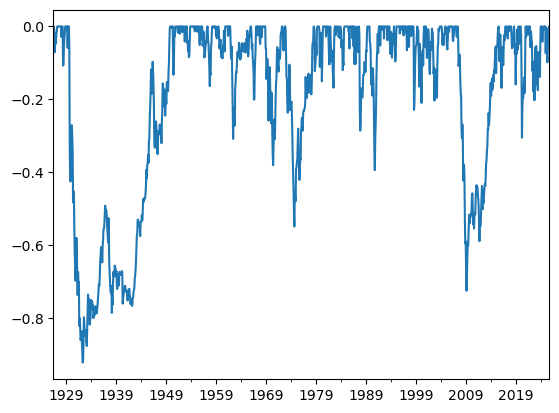

In [6]:
# look for drawdown for selected sectors
myfin.drawdown(ind["Fin"])["Drawdown"].plot.line()

In [7]:
#check the mean drawdown for all sectors
mean_dd = myfin.drawdown(ind["Fin"])["Drawdown"].mean()
mean_dd

np.float64(-0.19120385140582583)

In [8]:
# Example usage for one sector (Fin):
dd_fin = myfin.drawdown(ind["Fin"])["Drawdown"]
top5_fin = myfin.get_top_drawdowns(dd_fin, top=5)
print(top5_fin.sort_values(by="trough_value",ascending=True))

     start trough_date  trough_value      end  duration
0  1929-09     1932-05     -0.921232  1949-10       242
1  2007-06     2009-02     -0.724604  2015-06        97
2  1972-12     1974-09     -0.548414  1978-07        68
3  1989-10     1990-10     -0.393820  1991-07        22
4  1968-12     1970-06     -0.380178  1972-02        39


In [9]:
top5_fin["trough_value"].mean()

np.float64(-0.593649544921351)

In [10]:
# Example usage for multiple columns (DataFrame returned by myfin.drawdown):
# if myfin.drawdown(ind[cols]) returns a DataFrame where each column is a drawdown series:
cols = ["Fin","Oil","Steel"]
dd_df = pd.concat([ myfin.drawdown(ind[c])["Drawdown"].rename(c) for c in cols ], axis=1)
# collect top-5 per column
top_all = {c: myfin.get_top_drawdowns(dd_df[c], top=5) for c in dd_df.columns}
# to inspect top 5 of 'Fin':
print(top_all["Oil"])

     start trough_date  trough_value      end  duration
0  1929-09     1932-05     -0.763522  1936-11        87
1  2014-07     2020-03     -0.647509  2022-02        92
2  1937-04     1940-05     -0.495182  1943-02        71
3  1980-12     1982-07     -0.489422  1985-03        52
4  2008-07     2009-02     -0.475460  2011-03        33


We check the sharpe ratio for the total market, and make a range list out of them.

Lear to output data in ascend & descend order

In [11]:
myfin.sharpe_ratio(ind, 0.03, 12).sort_values()  # try the parameter: ascending=False

Coal     0.086381
Steel    0.144133
Txtls    0.166273
Whlsl    0.177600
Other    0.193189
Books    0.193233
Games    0.200908
Trans    0.215870
Mines    0.217605
Clths    0.255201
Autos    0.256662
Cnstr    0.268948
Servs    0.269727
Fin      0.285454
Carry    0.290197
FabPr    0.292059
ElcEq    0.295277
Hshld    0.301164
Oil      0.319380
Chems    0.319903
Util     0.320867
Beer     0.334761
Paper    0.336431
Meals    0.337417
Telcm    0.360810
Rtail    0.385904
BusEq    0.396683
Hlth     0.431635
Food     0.443253
Smoke    0.461599
dtype: float64

<Axes: >

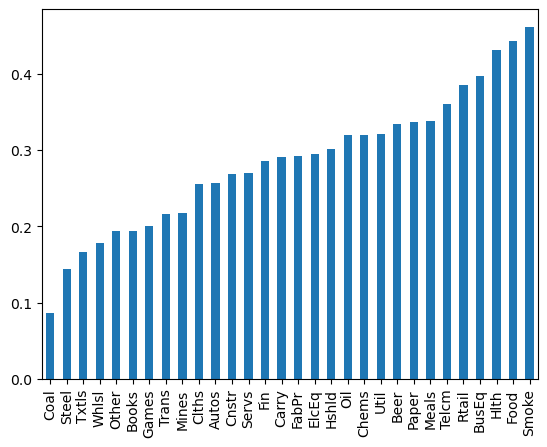

In [12]:
# visualization of the sharpe ratio over periods
myfin.sharpe_ratio(ind["1926":"2025"], 0.03, 12).sort_values().plot.bar()

<Axes: title={'center': 'Industry Sharpe Ratios since 2000'}>

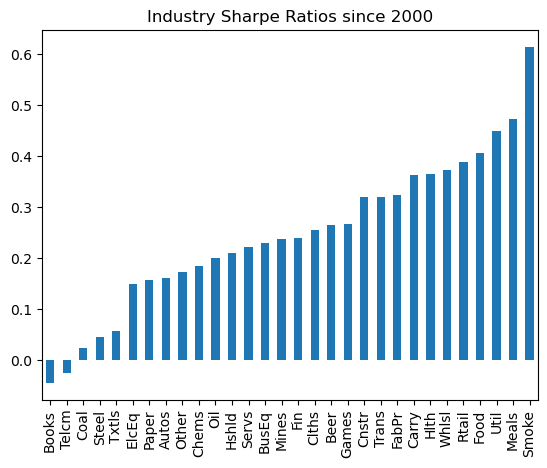

In [13]:
myfin.sharpe_ratio(ind["2000":], 0.03, 12).sort_values().plot.bar(title='Industry Sharpe Ratios since 2000')

#### 有效前沿模型的实战计算

需要先计算投资组合的预期收益和风险，风险（=标准方差）计算需要协方差矩阵covariance matrix：
- 前者需要重新计算收益率（调用库中的函数portfolio_return()）
- 后者可以直接调用Pandas DataFrame`.cov`方法和函数portfolio_vol（）。

我们先来做一些基础计算，打通算法环节

In [14]:
# compute the annualized returns and the covariance matrix
an_ret = myfin.annualize_rets(ind["1995":"2025"], 12)
an_ret.head()
 

Food     0.092046
Beer     0.088449
Smoke    0.141155
Games    0.107540
Books    0.053099
dtype: float64

In [15]:
cov = ind["1995":"2025"].cov()
cov.shape

(30, 30)

知道了全局数据的计算算法，我们可以尝试组建自己的（模拟）资产账户，然后对其进行收益率和波动率的计算（returns and volatility of a portfolio）。

需要的输入信息：
- set of weights（各组分的权重/占比）, 
- 各组分的收益率returns
- covariance matrix.

In [16]:
complist = ["Food", "Beer", "Smoke", "Coal"]
an_ret[complist]

Food     0.092046
Beer     0.088449
Smoke    0.141155
Coal     0.063597
dtype: float64

In [17]:
cov.loc[complist, complist]

,Food,Beer,Smoke,Coal
Food,0.001413,0.001210,0.001286,0.001112
Beer,0.001210,0.002185,0.001110,0.000976
Smoke,0.001286,0.001110,0.004393,0.001407
Coal,0.001112,0.000976,0.001407,0.016992


In [18]:
weights = np.array([0.2, 0.3, 0.4, 0.1])
# weights = np.repeat(0.25, 4)
print("Information about my portfolio:")
print(f"Portfolio components: {complist}")
print(f"Portfolio weights: {weights}")
print(f"Portfolio return: {myfin.portfolio_return(weights, an_ret[complist])}")
print(f"Portfolio volatility: {myfin.portfolio_vol(weights, cov.loc[complist, complist])}")

Information about my portfolio:
Portfolio components: ['Food', 'Beer', 'Smoke', 'Coal']
Portfolio weights: [0.2 0.3 0.4 0.1]
Portfolio return: 0.10776562508337252
Portfolio volatility: 0.0442580791002227


每个人都会问的问题：
1. 如何选择最好的组分构建我们的资产账户？
2. 每个组分的最优占比/权重是多少？

这些问题就可以引出有效前沿的概念来分析和实操。

我们首先学习构建一个**有效前沿曲线**

The 2-Asset Case

Let's write a function that draws the efficient frontier for a simple 2 asset case.

In the case of 2 assets, the problem is simplified, since the weight of the second asset is 1-the weight of the first asset.

Python coding technique to use a list: list comprehension

<Axes: xlabel='V', ylabel='R'>

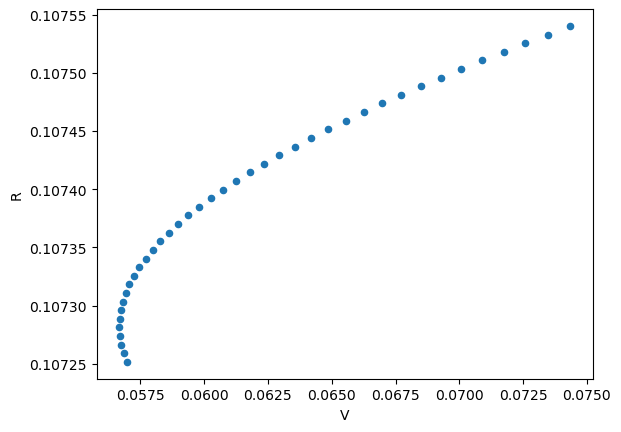

In [19]:
n_points = 40
weights = [np.array([w, 1-w]) for w in np.linspace(0, 1, n_points)]
cl2 = ["Games", "Fin"]
rets = [myfin.portfolio_return(w, an_ret[cl2]) for w in weights]
vols = [myfin.portfolio_vol(w, cov.loc[cl2, cl2]) for w in weights]
ef = pd.DataFrame({"R": rets, "V": vols})
ef.plot.scatter(x="V", y="R")

<Axes: xlabel='Volatility'>

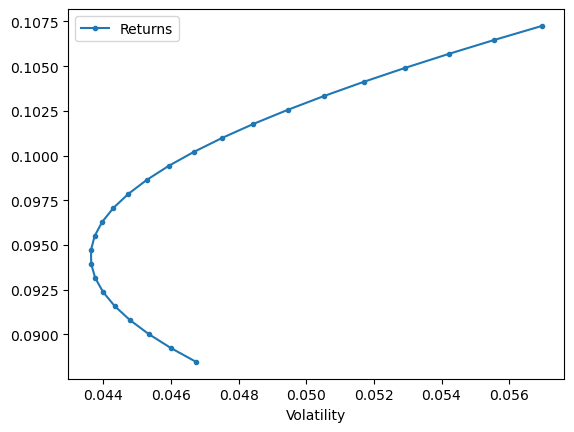

In [20]:
cl2 = ["Fin", "Beer"]
myfin.plot_ef_2ass(25, an_ret[cl2].values, cov.loc[cl2, cl2])

阶段性数据分析的收获：
- 从理论上理解了有效前沿的概念，知道如何用Python来计算和可视化

继续思考提出疑问：
- 如何从2组分的资产组合中扩展到多组分的资产组合？
- 如何在实践中用好有效前沿的概念？
- 如何计算出真实的有效前沿曲线？
  - 是否可以计算出真实的曲线=最优解曲线？
  - 曲线的关键参数是哪个？（注：可变参数在机器学习中称为模型的超级参数Hyperparameter）

分析结论：
- 最优曲线的确定在已知数据的基础上还需要一个参数：组分权重
- 获取了最优组分权重就可以计算出有效前沿曲线
- 而确定最优权重是一个优化问题，需要一个函数来优化这个问题： 给出某个年化收益，输出一个最小（！）的波动率.



In [63]:
#学习函数 minimize_vol
# 用一个EF曲线上的点来测试验证
weights_test= myfin.minimize_vol(0.106, an_ret[cl2], cov.loc[cl2, cl2])
vol_test = myfin.portfolio_vol(weights_test, cov.loc[cl2, cl2])
vol_test



np.float64(0.05474906859483902)

验证成功，现在我们可以算出组分权重来计算已知预期收益条件下的最小化波动率，还可以图形中画出最大和最小可能的收益率区间， 好处是：我们可以自由判断和决策资产组合的构建=处理目标收益率和最小波动率的关系。

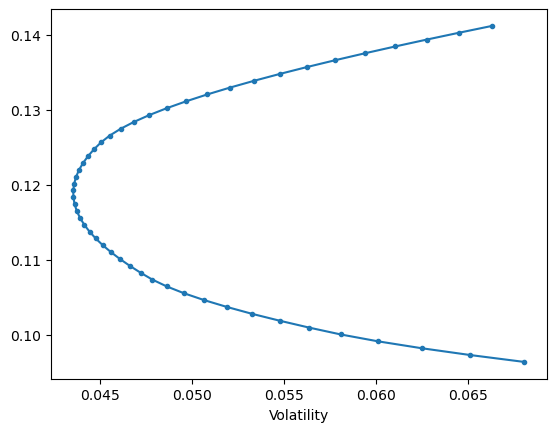

In [24]:
cl3 = ["Smoke", "Fin", "Oil", "Meals"]
ef3=myfin.plot_ef(50, an_ret[cl3], cov.loc[cl3, cl3])

虽然理论上Markowitz procedure（有效前沿）是成立的，但在实践中却会入坑。实效性的关键处在于不确定性：我们无法准确获得未来的预期收益率和预期Covariance矩阵。叠加在计算Covariance矩阵时总会带来计算误差，这些小偏差可能会带来高度敏感的影响，以至于无法正常使用该理论。

让我们用一个简单的2组分组合来理解和分析这个问题

In [64]:
#构建一个测试组合
ind4=myfin.get_ind_returns()
rets4=myfin.annualize_rets(ind4["1996":"2000"], 12)
cov4 = ind4["1996":"2000"].cov() 
cl4=["Food","Steel"]
wet4=myfin.msr(0.03, rets4[cl4], cov4.loc[cl4, cl4])
wet4

array([0.81878626, 0.18121374])

In [55]:
rets4[cl4]

Food     0.112763
Steel    0.082113
dtype: float64

In [65]:
myfin.msr(0.03, np.array([0.11, 0.1]), cov.loc[cl4, cl4])

array([1.00000000e+00, 1.66533454e-16])

In [66]:
myfin.msr(0.03, np.array([0.1, 0.8]), cov.loc[cl4, cl4])

array([5.55111512e-17, 1.00000000e+00])

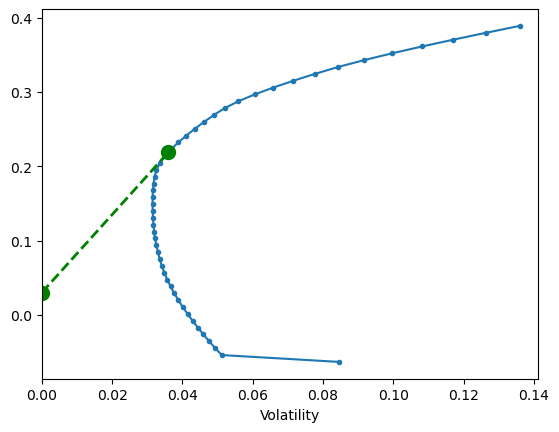

In [67]:
myfin.plot_ef(50, rets4, cov4, show_cml=True, riskfree_rate=0.03)

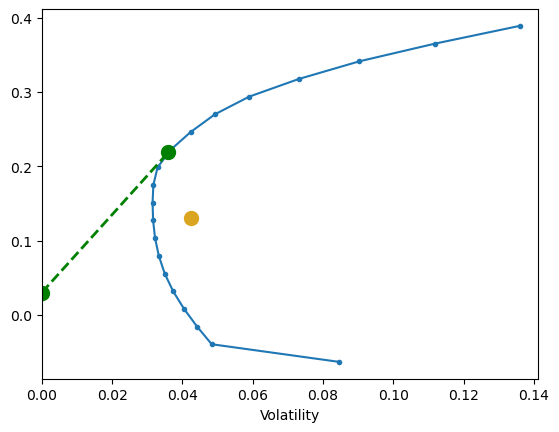

In [60]:
# case study: Let's keep all weights equal and see how the portfolio performs over time
myfin.plot_ef(20, rets4, cov4, show_cml=True, riskfree_rate=0.03, show_ew=True)

array([1., 0.])

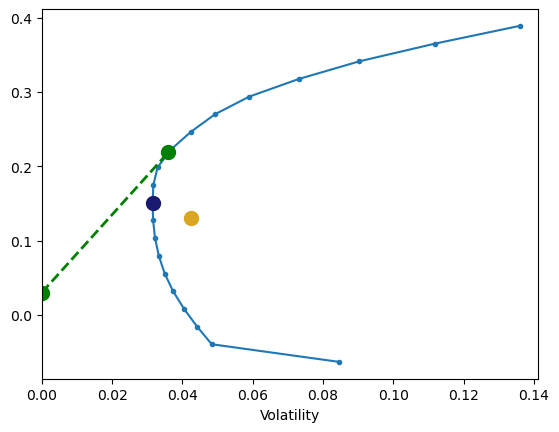

In [70]:
myfin.plot_ef(20, rets4, cov4, show_cml=True, riskfree_rate=0.03, show_ew=True, show_gmv=True)
wet4_best = myfin.minimize_vol(0.15, rets4[cl4], cov4.loc[cl4, cl4])
wet4_best

## Factor Modeling

因子分析计划：把观察到的历史数据BRKA 1990-May 2012拆分成一下组分：
- 市场给出的收益
- 剩下的是非市场给出的收益（隐含巴菲特的管理收益或运气成分）
- 底层市场基础模型：CAPM

模型：
$$ R_{brka,t} - R_{f,t} = \alpha + \beta(R_{mkt,t} - R_{f,t}) + \epsilon_t $$

数学计算：
- 线性回归模型：linear regression

In [40]:
brka_excess = brka_m["1990":"2012-05"] - fff.loc["1990":"2012-05", ['RF']].values
mkt_excess = fff.loc["1990":"2012-05",['SMB']]
brka_excess.shape, mkt_excess.shape
print(f"mkt_excess: \n {mkt_excess[:20]},\n brka_excess: \n {brka_excess[:20]}")

mkt_excess: 
             SMB
1990-01 -0.0129
1990-02  0.0103
1990-03  0.0152
1990-04 -0.0050
1990-05 -0.0257
1990-06  0.0143
1990-07 -0.0321
1990-08 -0.0358
1990-09 -0.0367
1990-10 -0.0551
1990-11  0.0033
1990-12  0.0079
1991-01  0.0379
1991-02  0.0395
1991-03  0.0389
1991-04  0.0050
1991-05 -0.0034
1991-06  0.0007
1991-07 -0.0093
1991-08  0.0159,
 brka_excess: 
                 BRKA
DATE                
1990-01-01 -0.146334
1990-02-01 -0.036552
1990-03-01 -0.075604
1990-04-01 -0.010617
1990-05-01  0.060364
1990-06-01  0.000693
1990-07-01 -0.034578
1990-08-01 -0.092314
1990-09-01 -0.088031
1990-10-01  0.005966
1990-11-01  0.060687
1990-12-01  0.046009
1991-01-01  0.103414
1991-02-01  0.086416
1991-03-01 -0.010592
1991-04-01  0.007161
1991-05-01  0.072223
1991-06-01 -0.044200
1991-07-01  0.009981
1991-08-01  0.024726


In [41]:
# ✅ Alternative: Use string-based alignment (more robust)
brka_period = brka_m.loc[period_start:period_end].copy()
fff_period = fff.loc[period_start:period_end].copy()

# Convert both indices to YYYY-MM string format
brka_period.index = brka_period.index.strftime('%Y-%m') if hasattr(brka_period.index, 'strftime') else brka_period.index.astype(str).str[:7]
fff_period.index = fff_period.index.strftime('%Y-%m') if hasattr(fff_period.index, 'strftime') else fff_period.index.astype(str).str[:7]

# Now both have matching string indices like "1990-01"
brka_excess = brka_period.squeeze() - fff_period['RF']
mkt_excess = fff_period['SMB']

data = pd.DataFrame({
    'BRKA_Excess': brka_excess,
    'Mkt_Excess': mkt_excess
}).dropna()

print(f"✅ Aligned: {len(data)} observations")



✅ Aligned: 269 observations


In [42]:
# ✅ Run regression using sklearn-based function
lm = myfin.regress(data['BRKA_Excess'], data[['Mkt_Excess']], alpha=True)
lm.summary()

Linear Regression Results (sklearn)
R-squared:           0.0510
Adj. R-squared:      0.0475
No. Observations:    269
Df Residuals:        267
Df Model:            1
Variable              Coef    t-value    p-value
----------------------------------------------------------------------
const               0.0096      2.588     0.0102
Mkt_Excess         -0.4131     -3.790     0.0002


In [44]:
mkt_excess = fff_period['HML']
data = pd.DataFrame({
    'BRKA_Excess': brka_excess,
    'Mkt_Excess': mkt_excess
}).dropna()

lm = myfin.regress(data['BRKA_Excess'], data[['Mkt_Excess']], alpha=True)
lm.summary()

Linear Regression Results (sklearn)
R-squared:           0.0340
Adj. R-squared:      0.0304
No. Observations:    269
Df Residuals:        267
Df Model:            1
Variable              Coef    t-value    p-value
----------------------------------------------------------------------
const               0.0080      2.136     0.0336
Mkt_Excess          0.3646      3.067     0.0024


In [45]:
mkt_excess = fff_period['Mkt-RF']
data = pd.DataFrame({
    'BRKA_Excess': brka_excess,
    'Mkt_Excess': mkt_excess
}).dropna()

lm = myfin.regress(data['BRKA_Excess'], data[['Mkt_Excess']], alpha=True)
lm.summary()

Linear Regression Results (sklearn)
R-squared:           0.1536
Adj. R-squared:      0.1504
No. Observations:    269
Df Residuals:        267
Df Model:            1
Variable              Coef    t-value    p-value
----------------------------------------------------------------------
const               0.0061      1.744     0.0822
Mkt_Excess          0.5402      6.961     0.0000


## 4. 模型评估 Model Evaluation <a id="4"></a> 

## 5. 业务理解/知识深化和提升  <a id="5"></a> 

总结：

有效前沿 = 投资世界的 “帕累托最优”边界，帮你找到风险与收益的最佳平衡组合。
- 核心工具：用于指导 “如何科学分散投资”，避免凭感觉配置。
- 口诀：“想要高收益就要冒高风险，但有效前沿能让你冒同样的风险时，收益最大化。”
- 分析得出：关键参数是个组分的权重（weight）（相对值），或组分仓位（绝对值）。是投资者实际操作中唯一可以自己操作且直接影响结果的动作
